### <div class="alert alert-block alert-info"><b>Import library<b><div>


In [1]:

# matplotlib → visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


### <div class="alert alert-block alert-info"><b>Load Cleaned Dataset<b><div>


In [2]:

# Load Cleaned ipl_data dataset
ipl_data=pd.read_csv( "../Datasets/ipl_dataset_cleaned.csv",low_memory=False)



### <div class="alert alert-block alert-info"><b>Basic Overview<b><div>


In [3]:
# First few rows

ipl_data.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,match_phase,is_super_over,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,year
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,Not Out,Not Out,NaN,Powerplay,0,2007/08,Bengaluru,2008-04-18,League,BB McCullum,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen,2008
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,No Extra,0,Not Out,Not Out,NaN,Powerplay,0,2007/08,Bengaluru,2008-04-18,League,BB McCullum,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen,2008
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,Not Out,Not Out,NaN,Powerplay,0,2007/08,Bengaluru,2008-04-18,League,BB McCullum,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen,2008
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,No Extra,0,Not Out,Not Out,NaN,Powerplay,0,2007/08,Bengaluru,2008-04-18,League,BB McCullum,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen,2008
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,No Extra,0,Not Out,Not Out,NaN,Powerplay,0,2007/08,Bengaluru,2008-04-18,League,BB McCullum,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Normal,Asad Rauf,RE Koertzen,2008


In [4]:
# Dataset information

ipl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251580 entries, 0 to 251579
Data columns (total 39 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          251580 non-null  int64  
 1   inning            251580 non-null  int64  
 2   batting_team      251580 non-null  object 
 3   bowling_team      251580 non-null  object 
 4   over              251580 non-null  int64  
 5   ball              251580 non-null  int64  
 6   batter            251580 non-null  object 
 7   bowler            251580 non-null  object 
 8   non_striker       251580 non-null  object 
 9   batsman_runs      251580 non-null  int64  
 10  extra_runs        251580 non-null  int64  
 11  total_runs        251580 non-null  int64  
 12  extras_type       251580 non-null  object 
 13  is_wicket         251580 non-null  int64  
 14  player_dismissed  251580 non-null  object 
 15  dismissal_kind    251580 non-null  object 
 16  fielder           89

### <div class="alert alert-block alert-info"><b>EDA-1 — Matches Played Per Year<b><div>


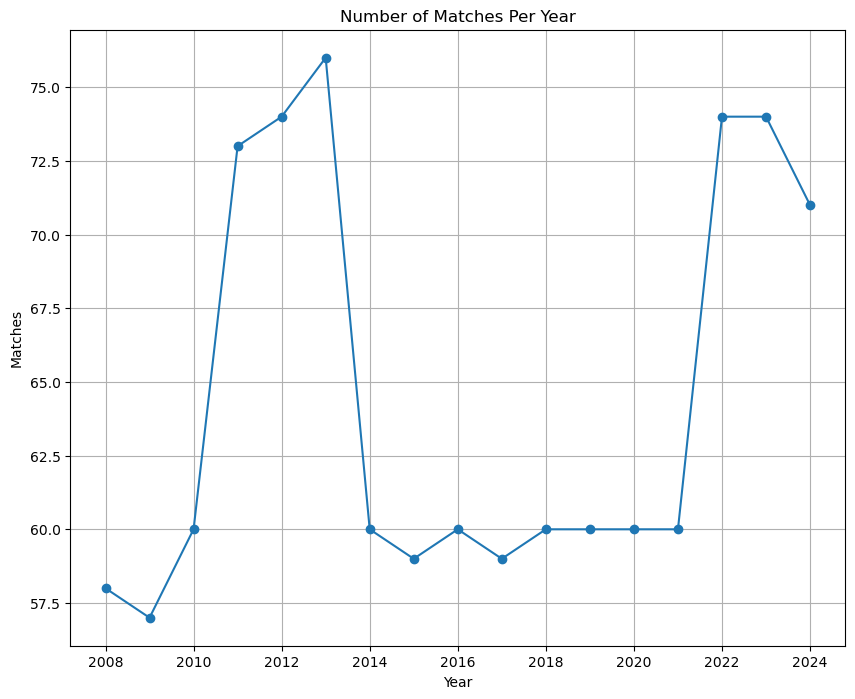

In [5]:

# MATCHES PER YEAR


matches_per_year = ipl_data.groupby("year")["match_id"].nunique()

plt.figure(figsize=(10,8))

plt.plot(

    matches_per_year.index,

    matches_per_year.values,

    marker="o"
)

plt.title("Number of Matches Per Year")

plt.xlabel("Year")

plt.ylabel("Matches")

plt.grid()

plt.show()

### <div class="alert alert-block alert-info"><b>EDA-2 matches Per venue<b><div>


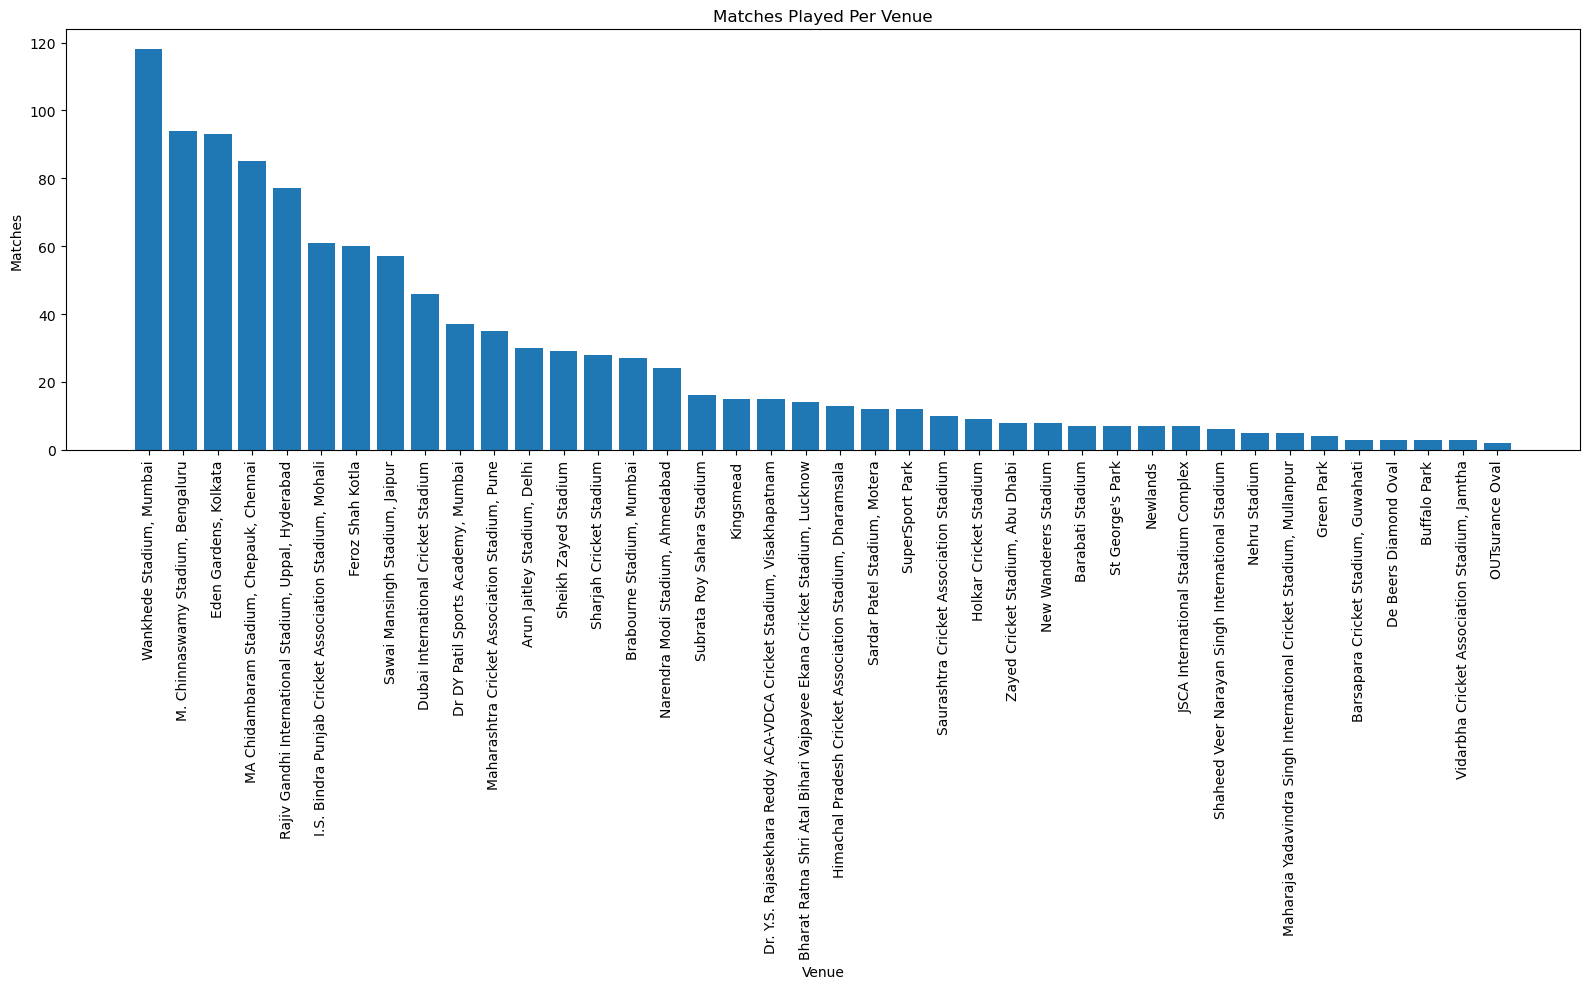

In [6]:
# ==========================================
# MATCHES PER VENUE
# ==========================================

venue_matches = ipl_data.groupby("venue")["match_id"].nunique().sort_values(ascending=False)

plt.figure(figsize=(16,10))

plt.bar(

    venue_matches.index,

    venue_matches.values
)

plt.xticks(rotation=90)

plt.title("Matches Played Per Venue")

plt.xlabel("Venue")

plt.ylabel("Matches")

plt.tight_layout()
plt.savefig("../images/matches_per_Venue.png", dpi=200)
plt.show()

### <div class="alert alert-block alert-info"><b>EDA -3 Toss Decision Analysis<b><div>


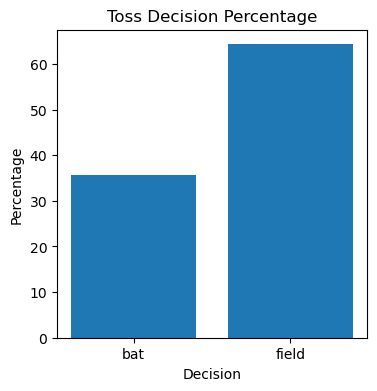

In [7]:
# ==========================================
# TOSS DECISION ANALYSIS
# ==========================================



toss_counts = ipl_data.groupby(
    "toss_decision"
)["match_id"].nunique()

toss_percent = (

    toss_counts /
    toss_counts.sum()

) * 100


plt.figure(figsize=(4,4))

plt.bar(
    toss_percent.index,
    toss_percent.values
)

plt.title("Toss Decision Percentage")
plt.xlabel("Decision")
plt.ylabel("Percentage")
plt.savefig("../images/Toss_Decision_percentage.png", dpi=150)
plt.show()

### <div class="alert alert-block alert-info"><b>EDA - 4 Top 10 Batsmen (Total Runs)<b><div>


In [8]:
# ==========================================
# BATTER PERFORMANCE METRICS
# ==========================================

# Total runs scored

batter_runs = ipl_data.groupby("batter")["batsman_runs"].sum()


# Matches played

batter_matches = ipl_data.groupby("batter")["match_id"].nunique()


# Balls faced

batter_balls = ipl_data.groupby("batter")["ball"].count()


# Times out

batter_outs = ipl_data[
    
    ipl_data["player_dismissed"] != "Not Out"

].groupby(
    
    "batter"

)["player_dismissed"].count()



# Strike Rate

strike_rate = ( batter_runs / batter_balls) * 100


# Batting Average

batting_average = (batter_runs / batter_outs )


# Runs per Match

runs_per_match = ( batter_runs /  batter_matches)


# Combine into dataframe

batter_stats = pd.DataFrame({

    "Runs": batter_runs,

    "Matches": batter_matches,

    "Balls": batter_balls,

    "Strike Rate": strike_rate,

    "Average": batting_average,

    "Runs per Match": runs_per_match

})


# Minimum match filter

batter_stats = batter_stats[
    
    batter_stats["Matches"] >= 30

]


batter_stats.head()

,Runs,Matches,Balls,Strike Rate,Average,Runs per Match
batter,,,,,,
A Badoni,598,35,476,125.630252,26.000000,17.085714
A Mishra,366,54,422,86.729858,12.620690,6.777778
A Symonds,939,36,751,125.033289,37.560000,26.083333
AB de Villiers,5007,170,3395,147.481591,40.707317,29.452941
AC Gilchrist,1983,80,1493,132.819826,26.092105,24.787500


In [9]:
# ==========================================
# TOP BATTERS
# ==========================================

top_batters = batter_stats.sort_values(
    
    by=["Runs", "Average", "Strike Rate"],
    
    ascending=False

).head(10)


top_batters

,Runs,Matches,Balls,Strike Rate,Average,Runs per Match
batter,,,,,,
V Kohli,7826,243,6055,129.248555,37.090047,32.205761
S Dhawan,6603,221,5320,124.116541,34.936508,29.877828
RG Sharma,6427,251,5045,127.393459,27.943478,25.605578
DA Warner,6382,184,4682,136.309270,39.639752,34.684783
SK Raina,5343,200,4038,132.317979,32.981481,26.715000
AB de Villiers,5007,170,3395,147.481591,40.707317,29.452941
MS Dhoni,5002,227,3779,132.363059,35.475177,22.035242
RV Uthappa,4797,197,3790,126.569921,26.502762,24.350254
CH Gayle,4719,141,3362,140.362879,38.056452,33.468085


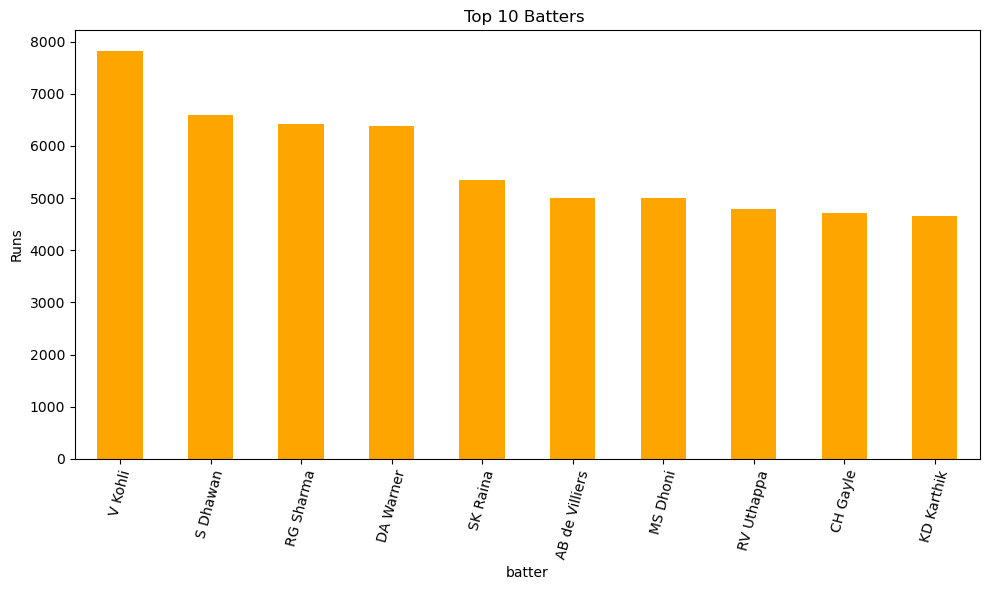

In [10]:
plt.figure(figsize=(10,6))

top_batters["Runs"].plot(
    
    kind="bar",
    color="orange"
)

plt.title( "Top 10 Batters ")

plt.ylabel("Runs")

plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("../images/Top_Batters.png", dpi=180)
plt.show()

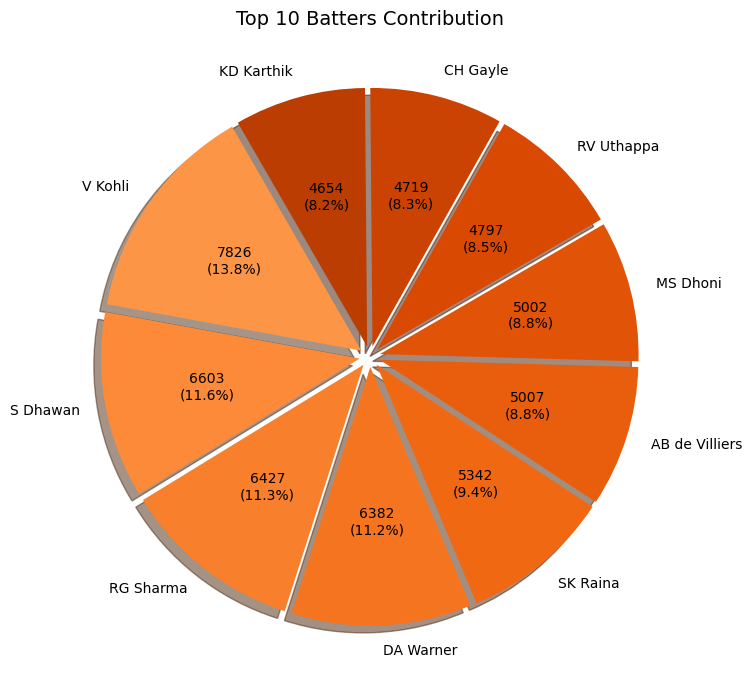

In [11]:
def func(pct, allvalues):
    
    absolute = int(pct/100.*sum(allvalues))
    
    return f"{absolute}\n({pct:.1f}%)"


plt.figure(figsize=(10,7))

# Dark Orange gradient colors
colors = plt.cm.Oranges(
    
    range(120, 120 + len(top_batters)*10, 10)
)

explode = [0.04]*len(top_batters)  # slight 3D separation

wedges, texts, autotexts = plt.pie(
    
    top_batters["Runs"],
    
    labels=top_batters.index,   # batter names
    
    autopct=lambda pct: func(pct, top_batters["Runs"]),
    
    startangle=120,
    
    colors=colors,
    
    explode=explode,
    
    shadow=True
)

plt.title("Top 10 Batters Contribution", fontsize=14)

plt.ylabel("")

plt.tight_layout()

plt.savefig("../images/Top_Batters.png", dpi=180)

plt.show()

### <div class="alert alert-block alert-info"><b>EDA 5 = Top 10 Bowlers (Total Runs)<b><div>


In [12]:
# ==========================================
# BOWLER PERFORMANCE METRICS
# ==========================================

# Total wickets

bowler_wickets = ipl_data[

    ipl_data["is_wicket"] == 1

].groupby(
    
    "bowler"

)["is_wicket"].count()



# Runs conceded

bowler_runs = ipl_data.groupby("bowler")["total_runs"].sum()


# Balls bowled

bowler_balls = ipl_data.groupby( "bowler" )["ball"].count()


# Overs bowled

bowler_overs = bowler_balls / 6


# Matches played

bowler_matches = ipl_data.groupby( "bowler" )["match_id"].nunique()


# Economy Rate

economy = ( bowler_runs / bowler_overs)


# Bowling Average

bowling_average = ( bowler_runs / bowler_wickets)


# Wickets per Match

wickets_per_match = ( bowler_wickets / bowler_matches )


# Combine dataframe

bowler_stats = pd.DataFrame({

    "Wickets": bowler_wickets,

    "Matches": bowler_matches,

    "Economy": economy,

    "Average": bowling_average,

    "Wickets per Match": wickets_per_match

})


# Minimum match filter

bowler_stats = bowler_stats[
    
    bowler_stats["Matches"] >= 30

]


bowler_stats.head()

,Wickets,Matches,Economy,Average,Wickets per Match
bowler,,,,,
A Kumble,48.0,42,6.652174,22.312500,1.142857
A Mishra,179.0,162,7.350934,23.072626,1.104938
A Nehra,113.0,88,7.804086,21.973451,1.284091
A Nortje,59.0,46,8.866351,26.423729,1.282609
A Symonds,23.0,30,7.730550,29.521739,0.766667


In [13]:
# ==========================================
# TOP BOWLERS 
# ==========================================

top_bowlers = bowler_stats.sort_values(
    
    by=["Wickets", "Economy"],
    
    ascending=[False, True]

).head(10)


top_bowlers

,Wickets,Matches,Economy,Average,Wickets per Match
bowler,,,,,
YS Chahal,202.0,159,7.736439,22.475248,1.270440
PP Chawla,199.0,191,8.002077,25.809045,1.041885
SP Narine,197.0,175,6.777560,23.406091,1.125714
DJ Bravo,197.0,158,8.110755,21.436548,1.246835
R Ashwin,191.0,208,6.972149,27.523560,0.918269
B Kumar,186.0,176,7.457428,26.134409,1.056818
SL Malinga,180.0,122,7.020509,18.383333,1.475410
JJ Bumrah,179.0,133,7.135241,20.435754,1.345865
A Mishra,179.0,162,7.350934,23.072626,1.104938


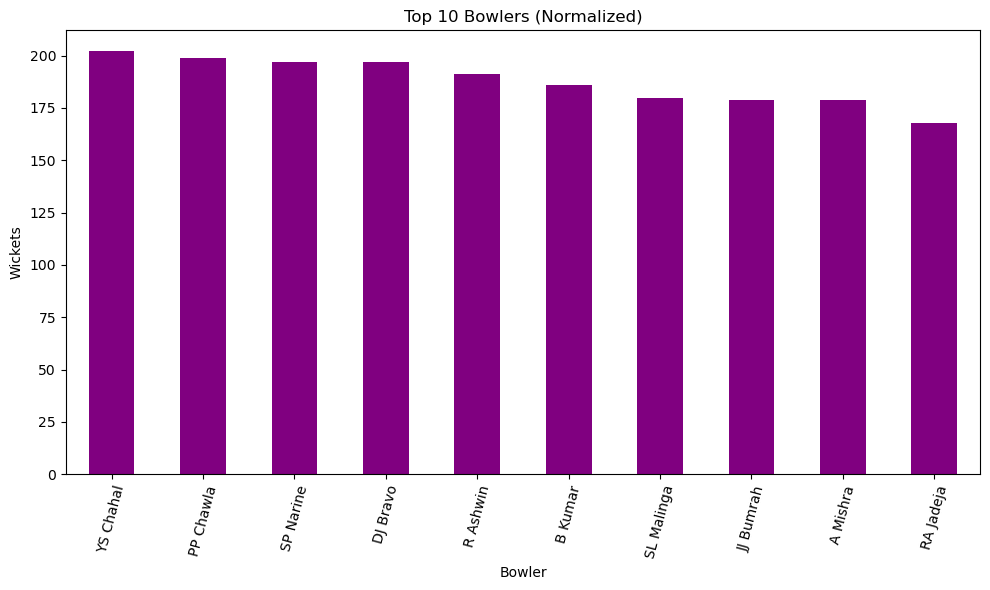

In [14]:
plt.figure(figsize=(10,6))

top_bowlers["Wickets"].plot(
    
    kind="bar",
    color="purple"
)

plt.title("Top 10 Bowlers (Normalized)")

plt.xlabel("Bowler")

plt.ylabel("Wickets")

plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

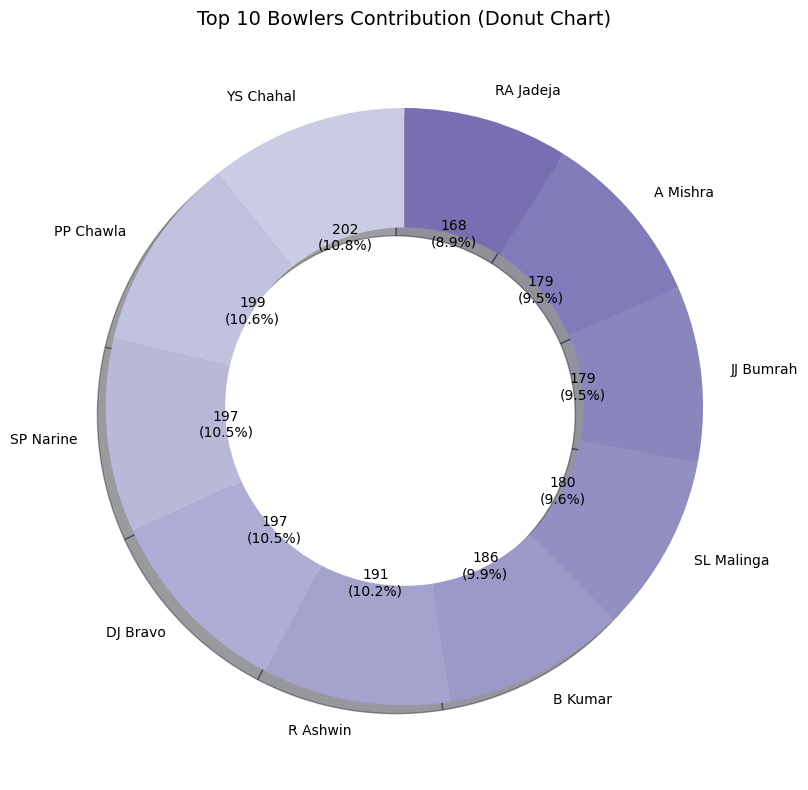

In [15]:
def func(pct, allvalues):
    
    absolute = int(pct/100.*sum(allvalues))
    
    return f"{absolute}\n({pct:.1f}%)"


plt.figure(figsize=(10,8))

colors = plt.cm.Purples(
    
    range(80, 80 + len(top_bowlers)*10, 10)
)

wedges, texts, autotexts = plt.pie(
    
    top_bowlers["Wickets"],
    
    labels=top_bowlers.index,   # ⭐ Bowler names added
    
    autopct=lambda pct: func(pct, top_bowlers["Wickets"]),
    
    startangle=90,
    
    colors=colors,
    
    wedgeprops=dict(width=0.4),   # donut hole
    
    shadow=True
)

plt.title("Top 10 Bowlers Contribution (Donut Chart)", fontsize=14)

plt.ylabel("")

plt.tight_layout()

plt.savefig("../images/Top_10_Bowlers.png", dpi=180)

plt.show()

### <div class="alert alert-block alert-info"><b>EDA - 6 = RUNS PER MATCH PHASE<b><div>


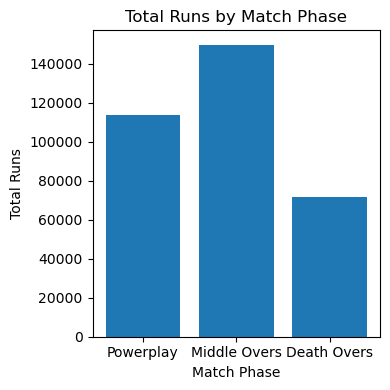

In [16]:
# ==========================================
# RUNS BY MATCH PHASE (ORDERED)
# ==========================================

# Step 1 — Group total runs by phase

phase_runs = ipl_data.groupby("match_phase")["total_runs"].sum()

# Step 2 — Define correct phase order

phase_order = ["Powerplay","Middle Overs","Death Overs"]

# Step 3 — Reorder phases

phase_runs = phase_runs.reindex(phase_order)

# Step 4 — Plot

plt.figure(figsize=(4,4))

plt.bar(
    phase_runs.index,

    phase_runs.values
)

plt.title("Total Runs by Match Phase")

plt.xlabel("Match Phase")

plt.ylabel("Total Runs")
plt.tight_layout()
plt.savefig("../images/Total_Runs_By_Match_phase.png", dpi=180)
plt.show()

### <div class="alert alert-block alert-info"><b>EDA - 7 Team Winning Count<b><div>


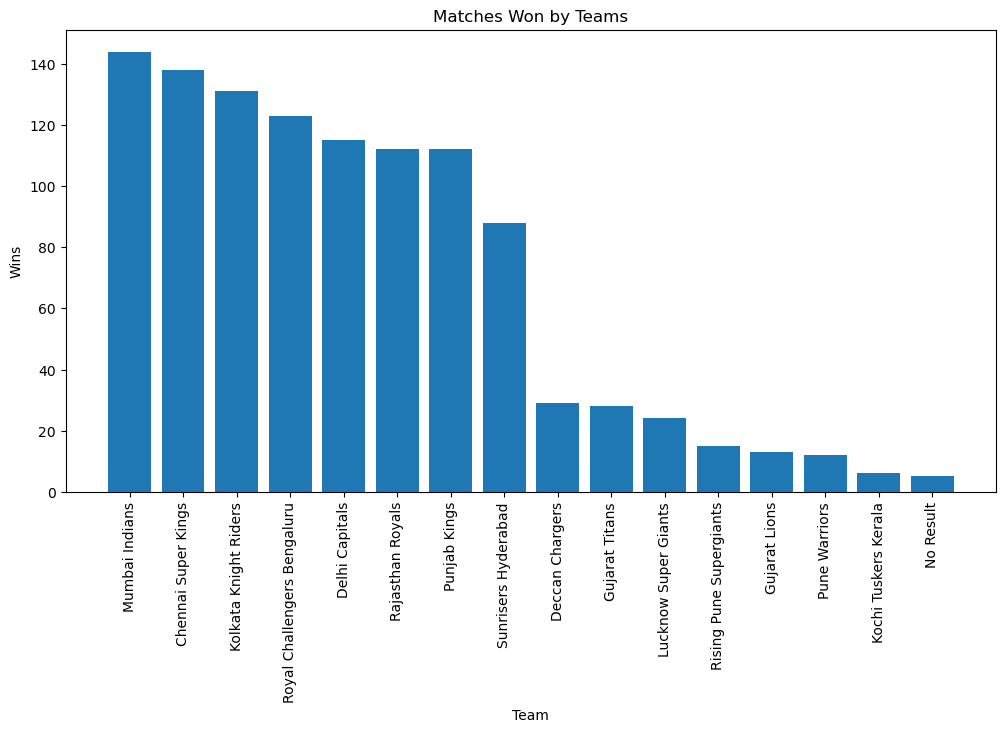

In [17]:
# ==========================================
# TEAM WINNING COUNT
# ==========================================

team_wins = ipl_data.groupby("winner")["match_id"].nunique().sort_values(ascending=False)

plt.figure(figsize=(12,6))

plt.bar(
    team_wins.index,

    team_wins.values
)

plt.xticks(rotation=90)

plt.title("Matches Won by Teams")

plt.xlabel("Team")

plt.ylabel("Wins")

plt.show()

### <div class="alert alert-block alert-info"><b>EDA - 8 Super Over Analysis<b><div>


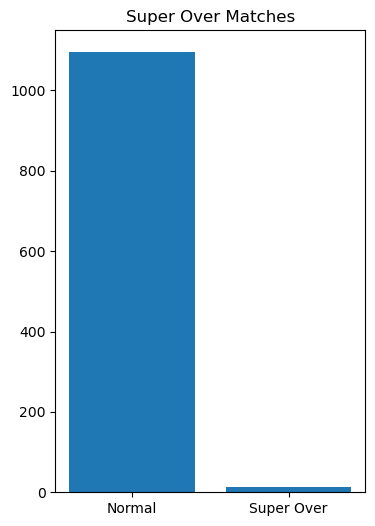

In [18]:
# ==========================================
# SUPER OVER ANALYSIS
# ==========================================

super_over_count = ipl_data.groupby("is_super_over")["match_id"].nunique()

plt.figure(figsize=(4,6))

plt.bar(

    ["Normal", "Super Over"],

    super_over_count.values

)

plt.title(
    "Super Over Matches"
)

plt.show()

### <div class="alert alert-block alert-info"><b>EDA - 9 Average Runs Per Over<b><div>


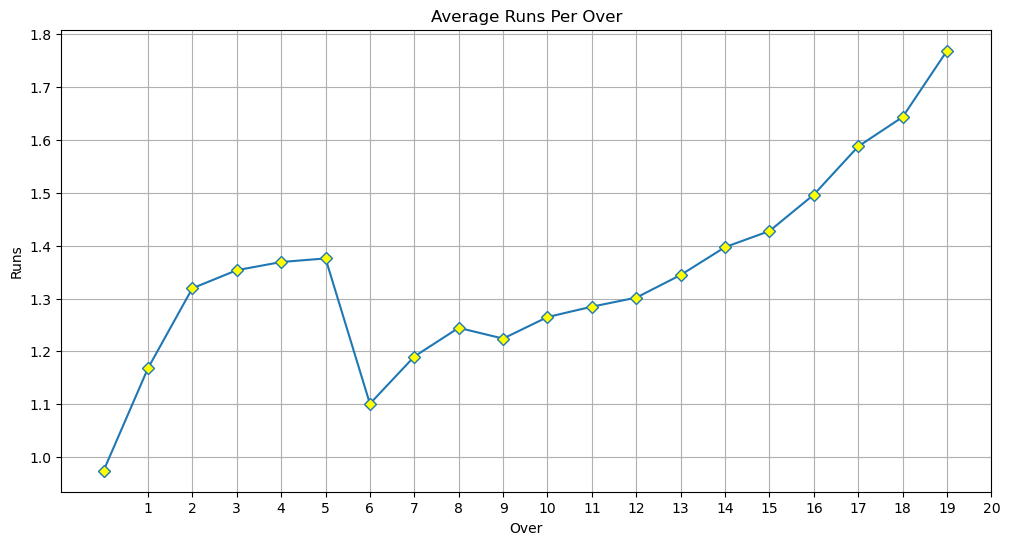

In [19]:
# ==========================================
# AVERAGE RUNS PER OVER
# ==========================================

runs_per_over = ipl_data.groupby(
    "over"
)["total_runs"].mean()


plt.figure(figsize=(12,6))

plt.plot(

    runs_per_over.index,

    runs_per_over.values,

    marker="D",
    markerfacecolor="yellow"

)
plt.xticks(range(1,21))

plt.title(
    "Average Runs Per Over"
)

plt.xlabel("Over")

plt.ylabel("Runs")

plt.grid()
plt.savefig("../images/Average_Runs_per_Over.png", dpi=300)
plt.show()